# GAN - Projet Vision Artificielle et traitement des images [8INF883]

Cédric GAUTHERET et Romain AMIGON

## Imports

In [1]:
try:
    import os
    import time

    import kagglehub
    import pandas as pd

    import matplotlib.pyplot as plt
    from PIL import Image
    import numpy as np

    import torch
    from torchvision import transforms
    from torch.utils.data import DataLoader, Dataset

    import torch.nn as nn
    import torch.optim as optim

    from torchinfo import summary
    import torchvision.utils as vutils
    from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity

except ImportError as e:
    print(f"Missing dependency : {e}")
    %pip install -r requirements.txt
    print("Please restart the kernel after installing the dependencies. Then re-run this cell to correctly import the libraries.")

/home/cedric/miniforge3/envs/my_ml312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

Le dataset **CelebFaces Attributes (CelebA)** est un jeu de données à grande échelle d'attributs faciaux contenant plus de $200 000$ images de célébrités.

La grande force de cette base de données réside dans sa diversité : elle intègre d'importantes variations de poses, des arrière-plans complexes et désordonnés, ainsi qu'une grande variété de profils humains. Le tout est soutenu par un volume massif d'images et des annotations d'une grande richesse. *(Ces données ont été initialement collectées par les chercheurs du MMLAB de l'Université chinoise de Hong Kong).*

Caractéristiques principales :
* Volume : 202 599 images de visages.
* Identités : 10 177 célébrités uniques.
* Annotations : 40 attributs binaires par image (ex. : *Souriant*, *Lunettes*, *Homme*, *Jeune*).
* Repères (Landmarks) : 5 points de repère par image (yeux, nez, coins de la bouche).

CelebA est une référence incontournable en vision par ordinateur pour l'entraînement des réseaux antagonistes génératifs (GAN). Sa grande diversité de poses, d'arrière-plans et de variations faciales le rend idéal pour générer des visages très réalistes.

Architecture des fichiers dans le dataset :
* ``img_align_celeba.zip`` : Le coeur du dataset. Il contient toutes les images de visages, qui ont déjà été **recadrées et alignées** (les yeux sont toujours à peu près au même niveau).
* ``list_eval_partition.csv`` : Ce fichier propose une répartition standardisée des images pour l'apprentissage :
    * **Train** : Images 1 à 162 770.
    * **Validation** : Images 162 771 à 182 637.
    * **Test** : Images 182 638 à 202 599.

> Etant donné que l'on ne va pas faire de la classification mais de la génération d'image, on n'a pas besoin d'utiliser une telle répartition.

* ``list_bbox_celeba.csv`` : Contient les informations des *bounding boxes* permettant de localiser précisément le visage dans l'image d'origine. Les colonnes `x_1` et `y_1` indiquent les coordonnées du coin supérieur gauche de la boîte, tandis que `width` et `height` en définissent la largeur et la hauteur.
* ``list_landmarks_align_celeba.csv`` : Fournit les coordonnées exactes (x, y) de 5 points clés du visage : l'oeil gauche, l'oeil droit, le nez, ainsi que les coins gauche et droit de la bouche.
* ``list_attr_celeba.csv`` : Le fichier des *labels*. Il répertorie les 40 attributs de chaque image. La valeur ``1`` indique que l'attribut est présent (positif), tandis que la valeur ``-1`` indique son absence (négatif).

On a choisi ce dataset pour ses **40 attributs** qui permettent de conditionner un **CGAN**. Au lieu de générer des visages de manière purement aléatoire, nous pourrons utiliser ces étiquettes pour diriger le modèle et générer des visages "à la carte". Par exemple, on pourra demander spécifiquement au générateur de créer "un homme blond avec des lunettes" ou "une femme souriante".

Pour notre **CGAN** basé sur des réseaux convolutifs (**CNN**), nous devrons prétraiter ces images. Nous allons les recadrer, les redimensionner à une taille standard et uniforme (ex. : 64x64), et normaliser la valeur de leurs pixels dans la plage [-1, 1] afin de correspondre à la fonction d'activation *Tanh* habituellement présente à la sortie du Générateur.

In [2]:
# download dataset
print("Downloading...")
dataset_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(f"Dataset downloaded to : {dataset_path}")

img_dir = os.path.join(dataset_path, "img_align_celeba", "img_align_celeba")

attr_path = os.path.join(dataset_path, "list_attr_celeba.csv")

Downloading...


100%|██████████| 1.33G/1.33G [00:29<00:00, 48.3MB/s]

Extracting files...


Dataset downloaded to : /home/cedric/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


### Exploration

In [3]:
img_names = os.listdir(img_dir)
img_names = [f for f in img_names if f.endswith('.jpg')]
img_names.sort()

print(f"Number of images : {len(img_names)}")

Number of images : 202599


On affiche les 10 premières images avec leur shape pour avoir une idée de la forme du dataset.

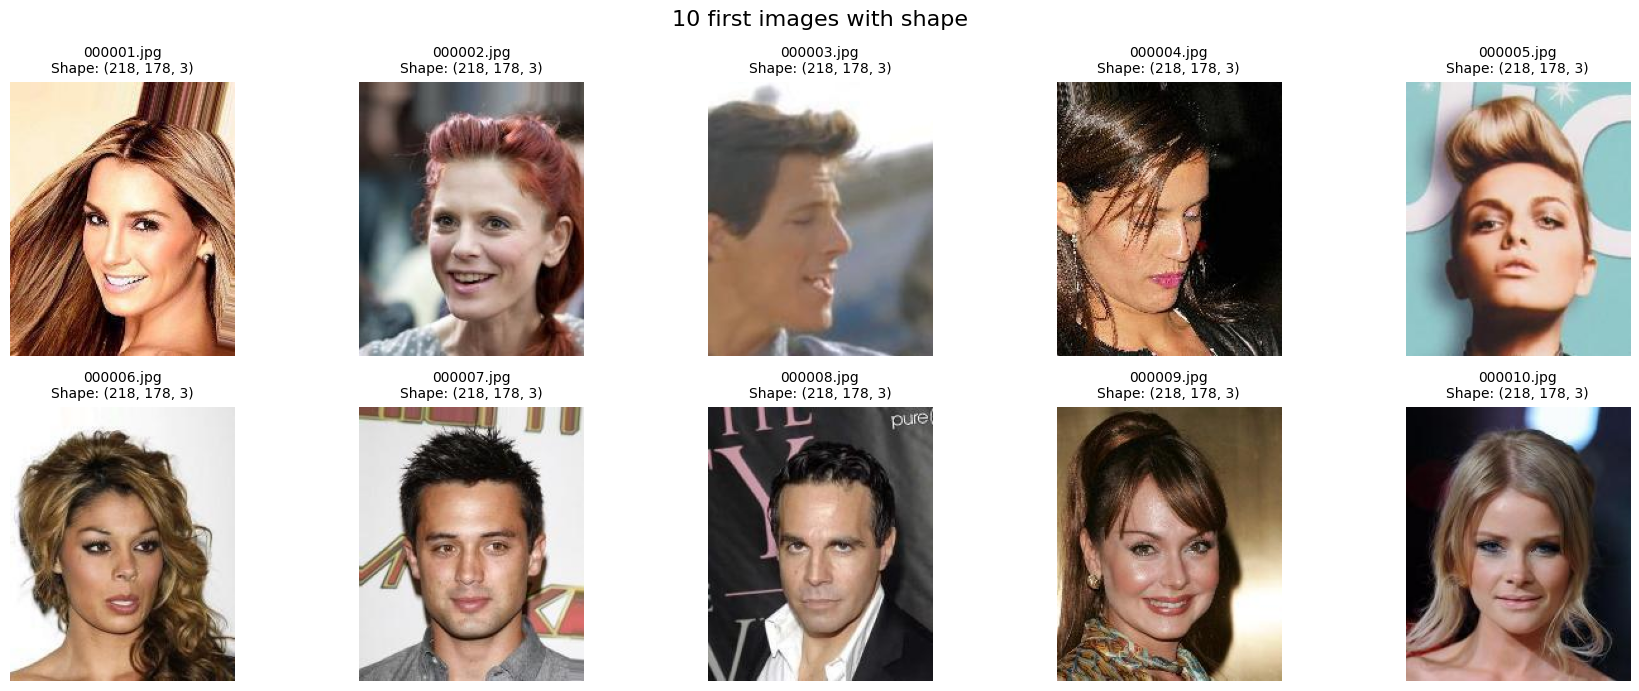

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, ax in enumerate(axes.flatten()):
    img_path = os.path.join(img_dir, img_names[i])
    img = Image.open(img_path)
    img_shape = np.array(img).shape
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{img_names[i]}\nShape: {img_shape}", fontsize=10)

plt.suptitle("10 first images with shape", fontsize=16)

plt.tight_layout()
plt.show()

On constate, en tout cas sur les 10 premières images qu'elles ont toutes la même shape. Elles semblent également toutes bien éclairés, on va donc se contenter d'un pipeline basique sans pré-traitement particulier et on verra par la suite selon les résultats du modèles si ça s'avère nécessaire.

In [5]:
unique_shapes = set()

print(f"Scanning {len(img_names)} images to verify shapes.")

for i, img_name in enumerate(img_names):
    img_path = os.path.join(img_dir, img_name)
    
    with Image.open(img_path) as img:
        # PIL 'img.size' returns (Width, Height). 
        # we format it to the standard (Height, Width, Channels) convention.
        # we also check the mode ('RGB' = 3 channels, 'L' = 1 channel grayscale).
        channels = 3 if img.mode == 'RGB' else (1 if img.mode == 'L' else img.mode)
        shape = (img.size[1], img.size[0], channels)
        
        # add the shape to our set
        unique_shapes.add(shape)
        
    if (i + 1) % 50000 == 0:
        print(f"Processed {i + 1}/{len(img_names)} images...")

print(f"Number of unique shapes found: {len(unique_shapes)}")
print("Unique shapes in the dataset (Height, Width, Channels):")

for shape in unique_shapes:
    print(f"- {shape}")

Scanning 202599 images to verify shapes.
Processed 50000/202599 images...
Processed 100000/202599 images...
Processed 150000/202599 images...
Processed 200000/202599 images...
Number of unique shapes found: 1
Unique shapes in the dataset (Height, Width, Channels):
- (218, 178, 3)


On vérifie donc que toutes les images ont la même taille : 218x178.
Pour autant, on appliquera un redimensionnement dans notre pré-traitement pour diminuer la taille des images.

On charge les attributs du CSV.

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
image_id,,,,,,,,,,,,,,,,,,,,,
000001.jpg,0,1,1,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
000002.jpg,0,0,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
000003.jpg,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
000004.jpg,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
000005.jpg,0,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


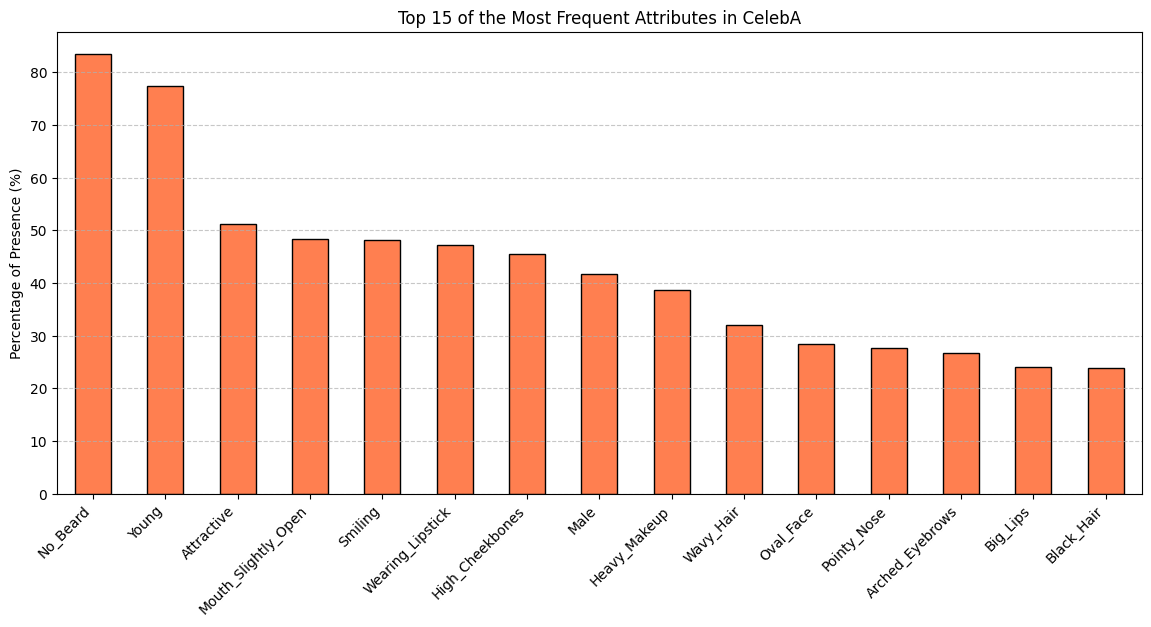


Most Rare Attributes :
Double_Chin    4.668829
Pale_Skin      4.294690
Gray_Hair      4.194986
Mustache       4.154512
Bald           2.244335
dtype: float64


In [6]:
df_attr = pd.read_csv(attr_path)
df_attr.set_index('image_id', inplace=True)

# replace -1 with 0
df_attr = df_attr.replace(-1, 0)

display(df_attr.head())

attr_percentages = df_attr.mean().sort_values(ascending=False) * 100

# Top 15
plt.figure(figsize=(14, 6))
attr_percentages[:15].plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 15 of the Most Frequent Attributes in CelebA')
plt.ylabel('Percentage of Presence (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Flop 5
print("\nMost Rare Attributes :")
print(attr_percentages[-5:])

Si les attributs sous-représentés posent problème, on les retirera du dataset.

In [7]:
attributes_list = df_attr.columns.tolist()

print(f"List of {len(attributes_list)} unique attributes :\n")
for i in range(0, len(attributes_list), 5):
    print(", ".join(attributes_list[i:i+5]))

List of 40 unique attributes :

5_o_Clock_Shadow, Arched_Eyebrows, Attractive, Bags_Under_Eyes, Bald
Bangs, Big_Lips, Big_Nose, Black_Hair, Blond_Hair
Blurry, Brown_Hair, Bushy_Eyebrows, Chubby, Double_Chin
Eyeglasses, Goatee, Gray_Hair, Heavy_Makeup, High_Cheekbones
Male, Mouth_Slightly_Open, Mustache, Narrow_Eyes, No_Beard
Oval_Face, Pale_Skin, Pointy_Nose, Receding_Hairline, Rosy_Cheeks
Sideburns, Smiling, Straight_Hair, Wavy_Hair, Wearing_Earrings
Wearing_Hat, Wearing_Lipstick, Wearing_Necklace, Wearing_Necktie, Young


On retiendra par exemple : ``Smiling``, ``Male``, ``No_Beard``, ``Wearing_Lipstick``, ``Eyeglasses``.

In [8]:
# computing the total count of occurrences for each attribute.
# since the values are 1 (present) and 0 (absent), summing the column gives the total count.
attribute_counts = df_attr.sum().sort_values(ascending=False)

# create a new DataFrame for better tabular visualization
df_counts = pd.DataFrame({
    'Attribute': attribute_counts.index,
    'Number of Occurrences': attribute_counts.values,
    'Percentage of Occurrence': (attribute_counts.values / len(df_attr) * 100).round(2)
})

print(f"Chart of attribute frequencies across {len(df_attr)} images :")
display(df_counts)

Chart of attribute frequencies across 202599 images :


,Attribute,Number of Occurrences,Percentage of Occurrence
0,No_Beard,169158,83.49
1,Young,156734,77.36
2,Attractive,103833,51.25
3,Mouth_Slightly_Open,97942,48.34
4,Smiling,97669,48.21
5,Wearing_Lipstick,95715,47.24
6,High_Cheekbones,92189,45.50
7,Male,84434,41.68
8,Heavy_Makeup,78390,38.69
9,Wavy_Hair,64744,31.96


### Pre-processing

Avant d'appliquer la normalisation, la fonction ``transforms.ToTensor()`` convertit l'image brute (dont les pixels ont des valeurs entières comprises entre **0 et 255**) en un tenseur PyTorch où les valeurs sont redimensionnées en nombres flottants compris entre **0.0 et 1.0**.

Nous allons appliquer une normalisation avec une moyenne de $0.5$ et un écart-type de $0.5$.
* **Pour un pixel noir (0.0) :** `(0.0 - 0.5) / 0.5 = -1.0`
* **Pour un pixel blanc (1.0) :** `(1.0 - 0.5) / 0.5 = 1.0`

> Toutes les valeurs de nos images réelles sont désormais étalées de manière symétrique sur la plage **[-1, 1]**.

Dans l'architecture classique d'un GAN, la toute dernière couche du **Générateur** utilise une fonction d'activation **Tanh (Tangente hyperbolique)**. 

La propriété mathématique de la fonction *Tanh* est de sortir exclusivement des valeurs comprises entre **-1 et 1**. 

Pour que le **Discriminateur** puisse faire son travail correctement et comparer de manière équitable les "fausses" images créées par le Générateur et les "vraies" images du dataset CelebA, on doit utiliser les mêmes échelles.

Les chercheurs ont en effet prouvé (notamment dans le papier de recherche fondateur du DCGAN) que l'utilisation de la plage [-1, 1] avec une activation *Tanh* aide le modèle à converger plus rapidement et de manière plus stable. Cela génère des images avec des contrastes plus forts et réduit le risque de disparition du gradient (*vanishing gradient*) pendant l'entraînement par rapport à une plage [0, 1].

In [9]:
IMAGE_SIZE = 64
BATCH_SIZE = 128
CHANNELS = 3

# For GANs, it is standard practice to normalize pixel values to the range [-1, 1].
# This matches the Tanh activation function typically used in the Generator's output layer.
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    # Normalize channels to [-1, 1] using mean=0.5 and std=0.5
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

class CelebADataset(Dataset):
    def __init__(self, root_dir, attr_df, transform=None):
        self.root_dir = root_dir
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.jpg')]
        self.attr_df = attr_df
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
            
        # load attributes for this specific image
        # convert to float tensor as they will be used in network calculations
        attributes = torch.tensor(self.attr_df.loc[img_name].values, dtype=torch.float32)
        
        return image, attributes

In [10]:
print("Initializing CelebA dataloader...")

celeba_dataset = CelebADataset(root_dir=img_dir, attr_df=df_attr, transform=transform)

dataloader = DataLoader(
    celeba_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,   # adjust based on CPU cores (on macos keep it at 0 to avoid multiprocessing issues due to spawn method)
    pin_memory=True
)

print(f"Dataset loaded successfully! Total batches per epoch: {len(dataloader)}")

# the expected shape in PyTorch is: (BATCH_SIZE, CHANNELS, HEIGHT, WIDTH)
images, attributes = next(iter(dataloader))
print(f"Shape of a single PyTorch batch: {images.shape}")

Initializing CelebA dataloader...
Dataset loaded successfully! Total batches per epoch: 1583
Shape of a single PyTorch batch: torch.Size([128, 3, 64, 64])


## CGAN

In [11]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Le modèle

Un réseau antagoniste génératif classique repose sur une compétition féroce entre deux modèles de neurones. 

Le premier est le Générateur, dont le but est de transformer un vecteur de bruit aléatoire abstrait, noté $z$, en une donnée réaliste, comme une image. 
Le second est le Discriminateur, qui agit comme un détective cherchant à séparer les véritables images provenant de la base de données de celles fabriquées par le Générateur. 

Dans un Conditional GAN, ou CGAN, cette dynamique est enrichie par l'ajout d'une information supplémentaire, notée $c$, qui représente une condition. Au lieu de générer des visages au hasard, le modèle apprend à lier des caractéristiques visuelles spécifiques à cette variable $c$. Mathématiquement, cette compétition se modélise par une fonction objectif minimax où le Générateur tente de minimiser la fonction que le Discriminateur cherche à maximiser. 

L'équation fondamentale du CGAN s'écrit donc $$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)}[\log D(x|c)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z|c)|c))]$$

Pour arbitrer ce jeu, nous utilisons la Binary Cross Entropy Loss, ou **BCELoss**. 

Étant donné que le rôle final du Discriminateur est de déterminer si une image est vraie ou fausse, le problème se résume à une classification binaire classique. La fonction Sigmoïde placée à la toute fin du réseau du Discriminateur comprime la sortie pour fournir une probabilité continue comprise entre $0$ et $1$. La BCELoss va alors mesurer la distance mathématique entre cette probabilité prédite et la véritable étiquette de l'image. 

Soit, $$\mathcal{L}_{BCE} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$ 

où $y_i$ représente l'étiquette réelle, valant $1$ pour une vraie image et $0$ pour une fausse, tandis que $\hat{y}_i$ représente la prédiction du modèle. 

Lors de l'entraînement, le Discriminateur cherche à minimiser cette erreur par rapport à la réalité, tandis que le Générateur calcule sa propre perte en passant ses fausses images au Discriminateur mais en cherchant à minimiser l'erreur par rapport à l'étiquette cible $1$, forçant ainsi le modèle à s'améliorer pour tromper son adversaire.

Dans notre implémentation spécifique, le Générateur est conçu selon les principes de l'architecture DCGAN, basée sur des convolutions profondes. Tout commence par la fusion de nos entrées. Nous prenons notre vecteur de bruit de dimension $100$ et le concaténons directement avec notre vecteur de conditions de dimension $40$. Le réseau démarre donc avec un volume d'entrée de dimension $140 \times 1 \times 1$. Pour transformer ce minuscule bloc d'informations en une image complète, nous utilisons des couches de convolutions transposées. Ces couches agissent à l'inverse des convolutions classiques en effectuant un suréchantillonnage spatial. À chaque étape, la résolution de notre image en devenir est doublée, passant de $4 \times 4$, puis $8 \times 8$, jusqu'à atteindre notre objectif de $64 \times 64$ pixels. 

Après presque chaque convolution, nous appliquons une normalisation par lot, ou BatchNorm, qui standardise les activations internes et empêche le modèle de diverger de manière chaotique lors des premières phases d'apprentissage. La non-linéarité est assurée par la fonction ReLU qui accélère la convergence. Enfin, la toute dernière couche utilise une activation Tanh pour forcer la sortie mathématique à se situer strictement dans l'intervalle $[-1, 1]$, correspondant exactement à l'échelle de normalisation que nous avons appliquée à nos images réelles lors du prétraitement.

Le Discriminateur effectue exactement le cheminement inverse. Puisqu'il est impossible de concaténer simplement un vecteur unidimensionnel de taille $40$ avec une image bidimensionnelle de taille $64 \times 64$, l'architecture commence par répéter le vecteur conditionnel sur toute la surface de l'image. Cela crée $40$ nouveaux canaux d'information, empilés virtuellement derrière les $3$ canaux de couleur RGB de l'image. La première couche de convolution reçoit donc une pile de données de $43$ canaux. Le réseau utilise ensuite une série de convolutions standards avec un pas, ou *stride*, de $2$. 

Ce choix architectural volontaire remplace les traditionnelles opérations de *MaxPooling*, laissant au réseau la liberté d'apprendre par lui-même la meilleure méthode pour réduire la résolution spatiale à chaque étape. Une caractéristique vitale de ce Discriminateur est l'utilisation exclusive de l'activation LeakyReLU avec une pente négative de $0.2$. Contrairement au ReLU standard qui met purement et simplement à zéro toutes les valeurs négatives, le LeakyReLU laisse passer un infime flux d'information. Cette astuce empêche le Discriminateur de bloquer complètement la circulation des gradients, garantissant que le Générateur reçoive toujours un retour d'information mathématique pour corriger ses erreurs, même lorsque ses fausses images sont facilement démasquées au début de l'entraînement.

In [12]:
# Hyperparameters for the networks
Z_DIM = 100         # Size of the random noise vector
C_DIM = 40          # Number of conditional attributes (CelebA)
FEATURES_GEN = 64   # Base number of feature maps in Generator
FEATURES_DISC = 64  # Base number of feature maps in Discriminator

# ---------------------------------------------------------
# GENERATOR NETWORK
# ---------------------------------------------------------
class Generator(nn.Module):
    def __init__(self, z_dim, c_dim, features_g):
        super(Generator, self).__init__()
        # Input to the first layer is noise (z_dim) + condition (c_dim)
        in_channels = z_dim + c_dim
        
        self.gen = nn.Sequential(
            # Input: (in_channels) x 1 x 1
            nn.ConvTranspose2d(in_channels, features_g * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            
            # State: (features_g*8) x 4 x 4
            nn.ConvTranspose2d(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            
            # State: (features_g*4) x 8 x 8
            nn.ConvTranspose2d(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            
            # State: (features_g*2) x 16 x 16
            nn.ConvTranspose2d(features_g * 2, features_g, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            
            # State: (features_g) x 32 x 32
            nn.ConvTranspose2d(features_g, CHANNELS, kernel_size=4, stride=2, padding=1, bias=False),
            # Output uses Tanh to map values to [-1, 1]
            nn.Tanh()
            # Final output: 3 x 64 x 64
        )

    def forward(self, x, labels):
        # Reshape labels to append them to the latent noise vector
        labels = labels.unsqueeze(2).unsqueeze(3) # Shape: (batch, C_DIM, 1, 1)
        # Concatenate noise and labels along the channel dimension
        x = torch.cat([x, labels], dim=1)
        return self.gen(x)

# ---------------------------------------------------------
# DISCRIMINATOR NETWORK
# ---------------------------------------------------------
class Discriminator(nn.Module):
    def __init__(self, c_dim, features_d):
        super(Discriminator, self).__init__()
        # Input channels = image channels (3) + condition channels (40)
        in_channels = CHANNELS + c_dim
        
        self.disc = nn.Sequential(
            # Input: (in_channels) x 64 x 64
            nn.Conv2d(in_channels, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (features_d) x 32 x 32
            nn.Conv2d(features_d, features_d * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (features_d*2) x 16 x 16
            nn.Conv2d(features_d * 2, features_d * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (features_d*4) x 8 x 8
            nn.Conv2d(features_d * 4, features_d * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (features_d*8) x 4 x 4
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid() # Output a probability [0, 1]
        )

    def forward(self, x, labels):
        # Expand labels to match the image spatial dimensions (64x64)
        labels = labels.unsqueeze(2).unsqueeze(3)
        labels = labels.repeat(1, 1, x.size(2), x.size(3)) # Shape: (batch, C_DIM, 64, 64)
        # Concatenate image and expanded labels
        x = torch.cat([x, labels], dim=1)
        return self.disc(x)

In [13]:
gen = Generator(Z_DIM, C_DIM, FEATURES_GEN).to(device)
disc = Discriminator(C_DIM, FEATURES_DISC).to(device)

# Generate dummy data to trace the models
# dummy inputs for Generator: Noise + Conditions
dummy_noise = torch.randn(BATCH_SIZE, Z_DIM, 1, 1, device=device)
dummy_cond_gen = torch.zeros(BATCH_SIZE, C_DIM, device=device)

# dummy inputs for Discriminator: Image + Conditions
dummy_image = torch.randn(BATCH_SIZE, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
dummy_cond_disc = torch.zeros(BATCH_SIZE, C_DIM, device=device)

In [14]:
summary(
    gen, 
    input_data=[dummy_noise, dummy_cond_gen], 
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18,
    row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape        Output Shape       Param #            Trainable
Generator (Generator)                    [128, 100, 1, 1]   [128, 3, 64, 64]   --                 True
├─Sequential (gen)                       [128, 140, 1, 1]   [128, 3, 64, 64]   --                 True
│    └─ConvTranspose2d (0)               [128, 140, 1, 1]   [128, 512, 4, 4]   1,146,880          True
│    └─BatchNorm2d (1)                   [128, 512, 4, 4]   [128, 512, 4, 4]   1,024              True
│    └─ReLU (2)                          [128, 512, 4, 4]   [128, 512, 4, 4]   --                 --
│    └─ConvTranspose2d (3)               [128, 512, 4, 4]   [128, 256, 8, 8]   2,097,152          True
│    └─BatchNorm2d (4)                   [128, 256, 8, 8]   [128, 256, 8, 8]   512                True
│    └─ReLU (5)                          [128, 256, 8, 8]   [128, 256, 8, 8]   --                 --
│    └─ConvTranspose2d (6)               [128, 256, 8, 8]   [128, 128, 1

In [15]:
summary(
    disc, 
    input_data=[dummy_image, dummy_cond_disc], 
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18,
    row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape        Output Shape       Param #            Trainable
Discriminator (Discriminator)            [128, 3, 64, 64]   [128, 1, 1, 1]     --                 True
├─Sequential (disc)                      [128, 43, 64, 64]  [128, 1, 1, 1]     --                 True
│    └─Conv2d (0)                        [128, 43, 64, 64]  [128, 64, 32, 32]  44,032             True
│    └─LeakyReLU (1)                     [128, 64, 32, 32]  [128, 64, 32, 32]  --                 --
│    └─Conv2d (2)                        [128, 64, 32, 32]  [128, 128, 16, 16] 131,072            True
│    └─BatchNorm2d (3)                   [128, 128, 16, 16] [128, 128, 16, 16] 256                True
│    └─LeakyReLU (4)                     [128, 128, 16, 16] [128, 128, 16, 16] --                 --
│    └─Conv2d (5)                        [128, 128, 16, 16] [128, 256, 8, 8]   524,288            True
│    └─BatchNorm2d (6)                   [128, 256, 8, 8]   [128, 256, 8

<img src="CGAN_diagram.png" alt="CGAN Diagram" width="500"/>

Pour que notre modèle prenne en compte les 40 attributs faciaux ($c$) :
* **Dans le Générateur :** Le vecteur de bruit aléatoire $z$ (de taille 100) est **concaténé** avec le vecteur d'attributs $c$ (de taille 40). Le réseau part donc d'un vecteur global de taille 140 pour générer l'image.
* **Dans le Discriminateur :** C'est un peu différent. On ne peut pas simplement ajouter 40 valeurs à une image de $64 \times 64$ pixels. On prend le vecteur de 40 attributs, et on "l'étire" spatialement pour créer 40 "calques" (canaux) de la taille de l'image. Le Discriminateur analyse donc un bloc de données composé de 3 canaux de couleurs (RGB) + 40 canaux de conditions, soit **43 canaux en entrée**.

#### 1) Le Générateur
L'objectif du Générateur est de transformer un simple vecteur de nombres en une image complexe de $64 \times 64$ pixels.

* **Convolutions Transposées (`ConvTranspose2d`) :** Au lieu de réduire l'image, ces couches font l'inverse : elles augmentent la résolution spatiale étape par étape (ex: $4 \times 4 \rightarrow 8 \times 8 \rightarrow 16 \times 16 \rightarrow \dots \rightarrow 64 \times 64$).
* **Normalisation par lot (`BatchNorm2d`) :** Appliquée après presque chaque couche, elle standardise les sorties intermédiaires. Cela stabilise énormément l'apprentissage et aide les gradients à circuler correctement dans le réseau.
* **Activation `ReLU` :** Utilisée dans les couches cachées pour introduire de la non-linéarité sans bloquer l'apprentissage (contrairement à la fonction Sigmoïde qui peut saturer).
* **Activation finale `Tanh` :** La dernière couche utilise la tangente hyperbolique pour forcer les pixels générés à se situer exactement dans la plage $[-1, 1]$, correspondant parfaitement à notre prétraitement des vraies images.

#### 2) Le Discriminateur
L'objectif du Discriminateur est de classifier l'image reçue : est-elle Vraie (1) ou Fausse (0) ?

* **Convolutions avec `stride=2` :** Dans les GANs modernes, on préfère utiliser des convolutions avec un "pas" (*stride*) de 2. Cela permet au réseau d'apprendre lui-même la meilleure façon de réduire la taille de l'image, plutôt que d'utiliser une opération mathématique figée comme le MaxPool.
* **Absence de BatchNorm sur la première couche :** C'est une règle d'or du DCGAN pour que le modèle puisse assimiler la distribution exacte des données réelles dès l'entrée, sans qu'elle soit altérée.
* **Activation `LeakyReLU(0.2)` :** Contrairement au `ReLU` classique qui remplace les valeurs négatives par $0$, le `LeakyReLU` laisse passer une légère pente d'information (0.2). Cela évite le problème des "neurones morts" et assure que le Discriminateur continue de fournir des gradients utiles au Générateur.
* **Activation finale `Sigmoid` :** Écrase la sortie finale pour renvoyer une probabilité nette comprise entre $0$ (100% sûr que c'est faux) et $1$ (100% sûr que c'est vrai).

L'optimiseur Adam (`lr=0.0002`, `betas=(0.5, 0.999)`) : Ces valeurs très spécifiques proviennent du papier de recherche original du DCGAN. Un taux d'apprentissage plus élevé, ou un paramètre *beta1* standard (0.9), entraîne presque toujours de fortes instabilités dans les GANs.

### Training

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import time  # module ajouté pour le chronométrage

# ---------------------------------------------------------
# CGAN Training Function with Time Tracking
# ---------------------------------------------------------
def train_cgan(gen, disc, dataloader, device, num_epochs=5, z_dim=100):
    """
    Trains the Conditional GAN and returns the loss history.
    """
    # optimizers
    opt_gen = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_disc = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

    # loss function
    criterion = nn.BCELoss()

    # lists to keep track of progress
    G_losses = []
    D_losses = []

    print("Starting Training Loop...")
    
    # record the start time
    start_time = time.time()

    for epoch in range(num_epochs):
        for batch_idx, (real_images, labels) in enumerate(dataloader):
            
            real_images = real_images.to(device)
            labels = labels.to(device)
            batch_size = real_images.shape[0]

            # Targets for BCE Loss (1 for real, 0 for fake)
            # we use a slight label smoothing (0.9 instead of 1.0) for real images to stabilize training
            real_targets = torch.full((batch_size, 1, 1, 1), 0.9, device=device)
            fake_targets = torch.zeros((batch_size, 1, 1, 1), device=device)

            # =========================================================
            # Train Discriminator: Maximize log(D(x)) + log(1 - D(G(z)))
            # =========================================================
            disc.zero_grad()
            
            # loss on real images
            output_real = disc(real_images, labels)
            loss_disc_real = criterion(output_real, real_targets)
            
            # loss on fake images
            # generate random noise
            noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
            # generate fake images conditioned on the real labels
            fake_images = gen(noise, labels)
            
            output_fake = disc(fake_images.detach(), labels) # detach() prevents gradients from flowing into Generator
            loss_disc_fake = criterion(output_fake, fake_targets)
            
            # total Discriminator loss and backprop
            loss_disc = (loss_disc_real + loss_disc_fake) / 2
            loss_disc.backward()
            opt_disc.step()

            # =========================================================
            # Train Generator: Maximize log(D(G(z)))
            # =========================================================
            gen.zero_grad()
            
            # we want the discriminator to believe our fake images are real (target = 1)
            output_fake_for_gen = disc(fake_images, labels)
            
            loss_gen = criterion(output_fake_for_gen, torch.ones_like(output_fake_for_gen))
            loss_gen.backward()
            opt_gen.step()

            # save losses for plotting later
            G_losses.append(loss_gen.item())
            D_losses.append(loss_disc.item())

            # print progress every 200 batches
            if batch_idx % 200 == 0:
                print(f"Epoch [{epoch}/{num_epochs}] Batch {batch_idx}/{len(dataloader)} "
                      f"Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

    # record the end time and calculate duration
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # format time in hours, minutes, and seconds
    hours, rem = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(rem, 60)
    
    print("-" * 50)
    print("Training finished!")
    print(f"Total training time: {int(hours):02d}h {int(minutes):02d}m {int(seconds):02d}s")
    print("-" * 50)
    
    # return the recorded losses
    return G_losses, D_losses

L'entraînement étant très long, on teste d'abord sur seulement 5 époques.

In [17]:
gen_5 = Generator(Z_DIM, C_DIM, FEATURES_GEN).to(device)
disc_5 = Discriminator(C_DIM, FEATURES_DISC).to(device)

NUM_EPOCHS = 5

G_losses_5, D_losses_5 = train_cgan(gen_5, disc_5, dataloader, device, num_epochs=NUM_EPOCHS, z_dim=Z_DIM)

Starting Training Loop...
Epoch [0/5] Batch 0/1583 Loss D: 0.6953, Loss G: 1.7569
Epoch [0/5] Batch 200/1583 Loss D: 0.4107, Loss G: 2.8762
Epoch [0/5] Batch 400/1583 Loss D: 0.6369, Loss G: 2.5080
Epoch [0/5] Batch 600/1583 Loss D: 0.7240, Loss G: 2.8019
Epoch [0/5] Batch 800/1583 Loss D: 0.7645, Loss G: 3.3372
Epoch [0/5] Batch 1000/1583 Loss D: 0.6816, Loss G: 1.2617
Epoch [0/5] Batch 1200/1583 Loss D: 0.8913, Loss G: 1.5167
Epoch [0/5] Batch 1400/1583 Loss D: 0.4438, Loss G: 1.7724
Epoch [1/5] Batch 0/1583 Loss D: 0.4315, Loss G: 2.6329
Epoch [1/5] Batch 200/1583 Loss D: 0.2496, Loss G: 3.2635
Epoch [1/5] Batch 400/1583 Loss D: 0.4981, Loss G: 1.0551
Epoch [1/5] Batch 600/1583 Loss D: 0.3773, Loss G: 2.8682
Epoch [1/5] Batch 800/1583 Loss D: 0.4753, Loss G: 4.1102
Epoch [1/5] Batch 1000/1583 Loss D: 0.3910, Loss G: 4.1544
Epoch [1/5] Batch 1200/1583 Loss D: 0.3618, Loss G: 3.6122
Epoch [1/5] Batch 1400/1583 Loss D: 0.2946, Loss G: 2.6591
Epoch [2/5] Batch 0/1583 Loss D: 0.3567, Los

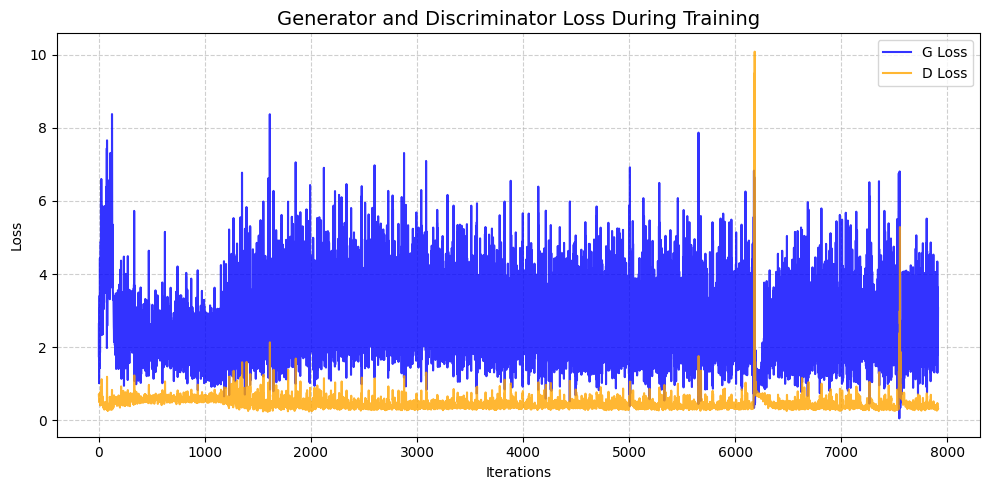

In [18]:
def plot_learning_curves(G_losses, D_losses):
    plt.figure(figsize=(10, 5))
    plt.title("Generator and Discriminator Loss During Training", fontsize=14)
    
    # Plot losses
    plt.plot(G_losses, label="G Loss", color='blue', alpha=0.8)
    plt.plot(D_losses, label="D Loss", color='orange', alpha=0.8)
    
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_learning_curves(G_losses_5, D_losses_5)

### Export/Import modèle

In [19]:
def export_cgan(generator, discriminator, save_dir, gen_name="cgan_generator.pth", disc_name="cgan_discriminator.pth"):
    """
    Exports the Generator and Discriminator weights to .pth files.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    gen_path = os.path.join(save_dir, f"{gen_name}")
    disc_path = os.path.join(save_dir, f"{disc_name}")
    
    torch.save(generator.state_dict(), gen_path)
    torch.save(discriminator.state_dict(), disc_path)
    
    print(f"Models exported successfully in: {save_dir}/")

export_cgan(gen_5, disc_5, save_dir="saved_models", gen_name="cgan_generator_5.pth", disc_name="cgan_discriminator_5.pth")

Models exported successfully in: saved_models/


In [20]:
def import_cgan(gen_path, disc_path, device, z_dim=100, c_dim=40, features_gen=64, features_disc=64):
    """
    Imports the Generator and Discriminator from .pth files and returns the loaded models.
    """
    # Re-initialize the networks with the same architecture
    gen = Generator(z_dim, c_dim, features_gen).to(device)
    disc = Discriminator(c_dim, features_disc).to(device)
    
    # Load the saved weights
    gen.load_state_dict(torch.load(gen_path, map_location=device))
    disc.load_state_dict(torch.load(disc_path, map_location=device))
    
    gen.eval()
    disc.eval()
    
    print("Models imported successfully, set to evaluation mode.")
    
    return gen, disc

## Tests et Résultats

On peut tester d'abord visuellement que les visages générés correspondent aux attributs que l'on donne.

In [38]:
def test_cgan_generation(generator, attributes_list, desired_attributes, device, num_images=5):
    """
    Generates images based on a dynamic list of desired conditions.
    """
    generator.eval() # set generator to evaluation mode
    
    # we create a base empty condition vector (all zeros)
    base_condition = torch.zeros(num_images, len(attributes_list)).to(device)
    
    valid_attributes = []
    
    # iterate through the provided list and activate each attribute
    for attr in desired_attributes:
        if attr in attributes_list:
            idx = attributes_list.index(attr)
            base_condition[:, idx] = 1.0
            valid_attributes.append(attr)
        else:
            print(f"Warning: Attribute '{attr}' not found. Skipping.")
            
    if not valid_attributes:
        print("No valid attributes provided. Generating with all zeros.")
    else:
        print(f"Testing Generator with conditions: {', '.join(valid_attributes)}")

    # generate random noise
    # Note: assuming Z_DIM is defined globally in your notebook
    noise = torch.randn(num_images, Z_DIM, 1, 1, device=device)
    
    # generate images without calculating gradients
    with torch.no_grad():
        fake_images = generator(noise, base_condition).detach().cpu()
        
    # unnormalize images from [-1, 1] to [0, 1] for visualization
    fake_images = (fake_images + 1) / 2.0
    
    # display the generated images in a grid
    plt.figure(figsize=(15, 6))
    plt.axis("off")
    
    # dynamically set the title
    title_str = "Generated Images"
    if valid_attributes:
        title_str += f" (Condition: {', '.join(valid_attributes)})"
    plt.title(title_str)
    
    plt.imshow(np.transpose(vutils.make_grid(fake_images, padding=2, normalize=False), (1, 2, 0)))
    plt.show()

Testing Generator with conditions: Smiling, Male, No_Beard


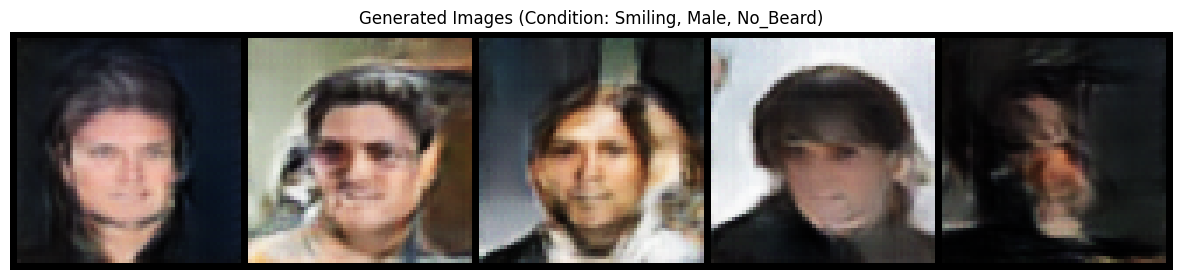

Testing Generator with conditions: Blond_Hair


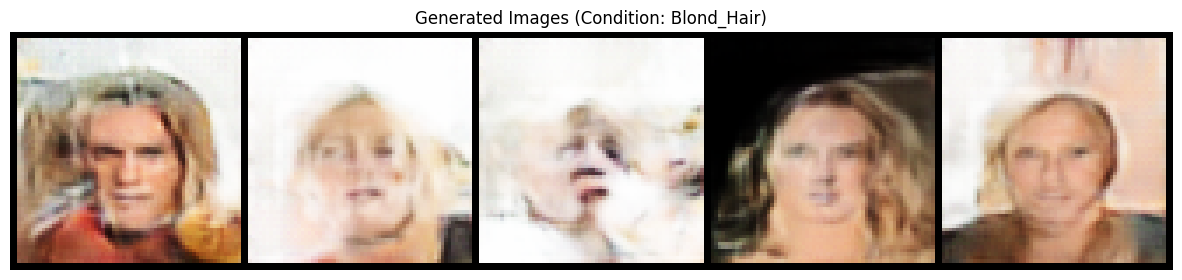

In [39]:
conditions_1 = ['Smiling', 'Male', 'No_Beard']
test_cgan_generation(gen_5, attributes_list, conditions_1, device, num_images=5)

conditions_2 = ['Blond_Hair']
test_cgan_generation(gen_5, attributes_list, conditions_2, device, num_images=5)

Il semble que l'on obtient bien des visages souriant et sans barbe, en revanche, pour ce qui est de savoir si c'est un homme ou une femme, c'est difficile car la corrélation pas de barbe + homme trouve surement 100% de cas chez les femmes donc le modèle associe pas de barbe à femme ce qui contredit le fait que l'on veut des hommes.

Pour comparer les images de manière plus formelle et obtenir une base pour l'optimisation d'hyperparamètres, on peut utiliser **LPIPS**.

Au lieu de comparer les pixels bruts, LPIPS (Learned Perceptual Image Patch Similarity) utilise un **réseau de neurones pré-entraîné** (généralement VGG16 ou AlexNet, entraîné sur des millions d'images réelles avec ImageNet) comme "oeil humain" pour comparer les images.

1. **Extraction des caractéristiques :** Les deux images à comparer passent à travers le réseau VGG.
2. **Récupération des activations :** LPIPS ne regarde pas la classification finale du réseau, mais s'arrête aux couches intermédiaires (les couches de convolution). Il extrait les *feature maps*, qui représentent les textures, les formes et les couleurs perçues par le réseau (espace latent).
3. **Calcul de la distance :** La métrique calcule la distance euclidienne entre ces cartes de caractéristiques pour chaque couche $l$, souvent pondérée par un vecteur $w$, selon la formule suivante :

$$d(x, x_0) = \sum_{l} \frac{1}{H_l W_l} \sum_{h, w} || w_l \odot (\hat{y}_{hw}^l - \hat{y}_{0hw}^l) ||_2^2$$

Où $\hat{y}$ représente les activations du réseau pour l'image $x$, et $\hat{y}_0$ les activations pour l'image $x_0$.

Contrairement à la précision (où plus haut = meilleur), LPIPS est une mesure de **distance** :

* **LPIPS proche de 0 :** Les deux images sont perceptuellement identiques.
* **LPIPS élevé (ex: > 0.5) :** Les deux images sont structurellement et visuellement très différentes.

Dans le cas d'un CGAN, nous n'avons pas d'image "cible" exacte pour calculer une erreur. Si on demande au modèle de générer "un homme à lunettes", il n'y a pas une seule bonne réponse, il en existe des millions.

Nous allons donc faire un test de diversité : nous donnons au Générateur la **même condition** (ex: "Femme, Souriante, Jeune") mais avec deux vecteurs de bruit différents ($z_1$ et $z_2$).
* Le modèle doit générer deux femmes différentes qui respectent ces critères. 
* Nous calculons le score LPIPS entre ces deux images générées.
   * Si le **LPIPS est très bas**, cela signifie que le GAN a triché. Il a mémorisé un seul visage de "Femme souriante" et le recrache en boucle peu importe le bruit $z$.
   * Si le **LPIPS est suffisamment élevé**, cela prouve que le Générateur a bien appris la distribution globale et est capable d'inventer des visages variés et uniques pour une même condition.

> Dans le contexte strict de l'évaluation de la diversité interne d'un GAN, un score LPIPS plus élevé indique une bonne performance.

In [32]:
def compute_generation_diversity(generator, base_condition, device, num_pairs=10):
    """
    Calculates LPIPS between pairs of images generated with the SAME condition 
    to ensure the model produces diverse outputs (avoids mode collapse).
    Higher LPIPS means better diversity.
    """
    generator.eval()
    lpips_metric = LearnedPerceptualImagePatchSimilarity(net_type='vgg').to(device)
    
    lpips_scores = []
    
    with torch.no_grad():
        for _ in range(num_pairs):
            # generate two different images using the exact same condition
            noise1 = torch.randn(1, Z_DIM, 1, 1, device=device)
            noise2 = torch.randn(1, Z_DIM, 1, 1, device=device)
            
            # we need batch size 1 for the condition here
            cond = base_condition[0].unsqueeze(0)
            
            img1 = generator(noise1, cond)
            img2 = generator(noise2, cond)
            
            # LPIPS expects images in range [-1, 1], which matches our generator output
            score = lpips_metric(img1, img2)
            lpips_scores.append(score.item())
            
    avg_lpips = sum(lpips_scores) / len(lpips_scores)
    print(f"Average LPIPS Diversity Score (Higher is better): {avg_lpips:.4f}")

# 1. Create a base condition tensor of zeros. 
# Shape is (1, 40) assuming batch size 1 and C_DIM = 40.
base_condition = torch.zeros(1, C_DIM).to(device)

# 2. Find the index of the "Smiling" attribute in list
# (Make sure you have your attributes_list defined from the data exploration step)
idx_smiling = attributes_list.index('Smiling')

# 3. Activate the "Smiling" attribute by setting its value to 1
base_condition[0, idx_smiling] = 1.0

# 4. Now call the function by passing the properly formatted tensor
compute_generation_diversity(gen_5, base_condition, device, num_pairs=10)

Average LPIPS Diversity Score (Higher is better): 0.6154


## Modèle final complet sur 30 époques

In [33]:
gen_30 = Generator(Z_DIM, C_DIM, FEATURES_GEN).to(device)
disc_30 = Discriminator(C_DIM, FEATURES_DISC).to(device)

NUM_EPOCHS = 30

G_losses_30, D_losses_30 = train_cgan(gen_30, disc_30, dataloader, device, num_epochs=NUM_EPOCHS, z_dim=Z_DIM)

export_cgan(gen_30, disc_30, save_dir="saved_models", gen_name="cgan_generator_30.pth", disc_name="cgan_discriminator_30.pth")

Starting Training Loop...
Epoch [0/30] Batch 0/1583 Loss D: 0.6962, Loss G: 1.1010
Epoch [0/30] Batch 200/1583 Loss D: 0.4362, Loss G: 2.6181
Epoch [0/30] Batch 400/1583 Loss D: 0.4694, Loss G: 3.3996
Epoch [0/30] Batch 600/1583 Loss D: 0.5336, Loss G: 2.5843
Epoch [0/30] Batch 800/1583 Loss D: 0.4413, Loss G: 2.5838
Epoch [0/30] Batch 1000/1583 Loss D: 0.4616, Loss G: 2.0698
Epoch [0/30] Batch 1200/1583 Loss D: 0.4876, Loss G: 2.4900
Epoch [0/30] Batch 1400/1583 Loss D: 0.3117, Loss G: 2.4945
Epoch [1/30] Batch 0/1583 Loss D: 0.4237, Loss G: 3.2398
Epoch [1/30] Batch 200/1583 Loss D: 0.6253, Loss G: 1.3269
Epoch [1/30] Batch 400/1583 Loss D: 0.4672, Loss G: 1.7356
Epoch [1/30] Batch 600/1583 Loss D: 0.3294, Loss G: 2.8123
Epoch [1/30] Batch 800/1583 Loss D: 0.3723, Loss G: 3.7130
Epoch [1/30] Batch 1000/1583 Loss D: 0.5210, Loss G: 4.5578
Epoch [1/30] Batch 1200/1583 Loss D: 0.3381, Loss G: 3.5294
Epoch [1/30] Batch 1400/1583 Loss D: 0.4382, Loss G: 4.5310
Epoch [2/30] Batch 0/1583 Lo

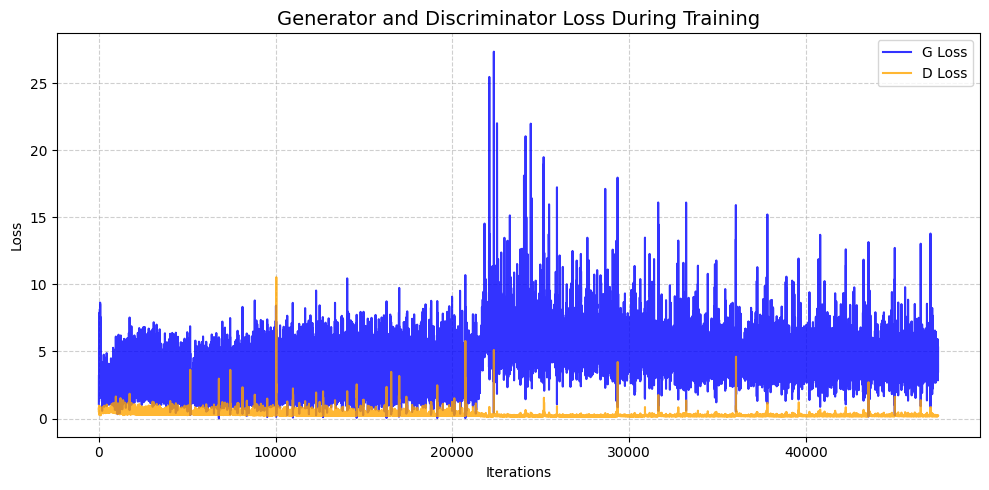

Average LPIPS Diversity Score (Higher is better): 0.5689


In [34]:
plot_learning_curves(G_losses_30, D_losses_30)

compute_generation_diversity(gen_30, base_condition, device, num_pairs=10)

Testing Generator with conditions: Smiling, Male, No_Beard


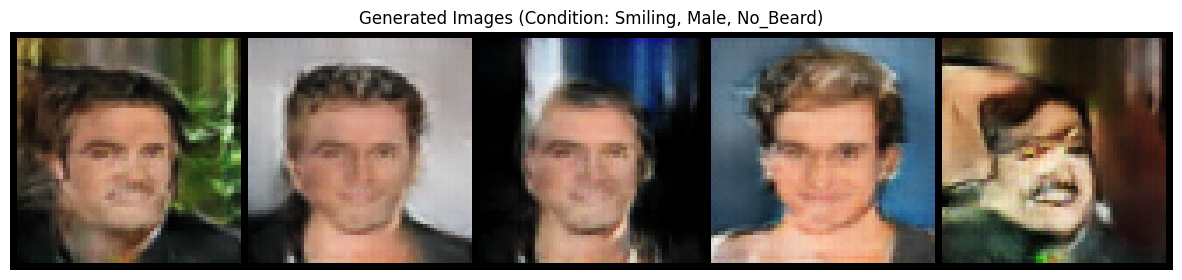

Testing Generator with conditions: Eyeglasses


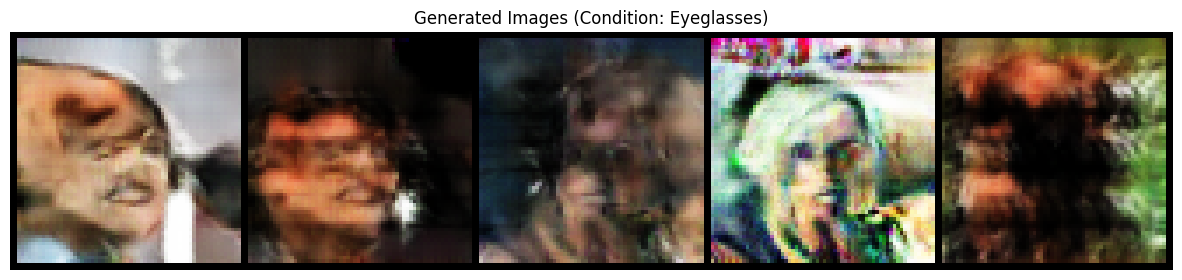

In [40]:
attributes1 = ['Smiling', 'Male', 'No_Beard']
test_cgan_generation(gen_30, attributes_list, attributes1, device, num_images=5)

attributes2 = ['Eyeglasses']
test_cgan_generation(gen_30, attributes_list, attributes2, device, num_images=5)

La classe ``Eyeglasses`` étant sous-représentée, on obtient des images glitchées, contrairement aux autres classes.

## Améliorations potentielles

Il pourrait être intéressant de faire de l'optimisation d'hyperparamètres avec un framework tel Optuna sur le modèle pour tenter de l'améliorer mais celà prendrait des jours et on se heurte à un problème quand il s'agit des modèles génératifs : quelle métrique à minimiser/optimiser choisir ?

En effet, puisque la Loss du Générateur et du Discriminateur jouent au chat et à la souris, une Loss basse pour l'un signifie une Loss haute pour l'autre, dans un environnement de recherche idéal, Optuna générerait des milliers d'images à la fin de chaque essai, calculerait le score FID (Fréchet Inception Distance), et chercherait à le minimiser. Cependant, cela prendrait des jours de calcul.

C'est pour cela que l'on utilise déjà les valeurs ``optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))`` qui sont celles qui ont données les meilleurs résultats dans les papiers de recherche sur le CGAN.